<a href="https://colab.research.google.com/github/Surendranmengineer/csb-usvwrt/blob/gh-pages/exercise01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 01 - CNN + RNN (Keras / TensorFlow)
Two architectures, two data types, one notebook.

**Part 1 — CNN on Fashion-MNIST** (images, spatial structure)
1. Load data
2. Build the CNN
3. Train and read the curves
4. Where does it fail? (per-class + misclassified images)
5. Improve: add Dropout, compare
6. What else you can try

**Part 2 — RNN on IMDB** (text sequences, temporal structure)
7. Load IMDB reviews
8. SimpleRNN — fast but forgets long context
9. LSTM — gates handle long context
10. Compare and improve

> **New to deep learning? Read this first.** A neural network learns by example: we
> show it inputs (images or text) with the correct answers, it makes guesses, measures
> how wrong it is, and nudges its internal numbers (*weights*) to do better next time.
> The words below appear throughout — keep this table handy.

| Term | Plain meaning |
|---|---|
| **epoch** | One full pass through all the training data. |
| **batch** | We update the model after a small group of examples (e.g. 64), not after every single one — faster and steadier. |
| **loss** | A number measuring how wrong the model is. Training tries to make it small. |
| **optimizer** | The rule for nudging the weights to reduce the loss (`adam`, `rmsprop` are popular ones). |
| **logits** | The model's raw output scores, before they are turned into probabilities. |
| **accuracy** | Fraction of examples the model gets right. |
| **train / validation / test** | Data the model *learns from* / a held-back slice to *watch for overfitting* / a final untouched slice to *grade* it. |
| **overfitting** | The model memorises the training data instead of learning general patterns — it scores high on train but low on data it hasn't seen. |

In [ ]:
import matplotlib.pyplot as plt          # charts and image grids
import numpy as np                       # arrays and math
import tensorflow as tf                  # the deep learning engine
from tensorflow import keras             # the high-level model-building API inside TF
from tensorflow.keras import layers, models  # layers = building blocks; models = the container

# Fix the random seed so results are the SAME every time you run this notebook.
# Without this, weight initialisation is random → accuracy numbers wobble on each run.
tf.random.set_seed(42)
np.random.seed(42)

# TensorFlow is the engine; Keras is the friendly layer-building API that ships inside it.
print('TensorFlow', tf.__version__, '| Keras', keras.__version__)

TensorFlow 2.20.0 | Keras 3.13.2


## 1 - Data
**Fashion-MNIST**: 28x28 grayscale photos of clothing, 10 categories.
`load_data()` downloads ~30 MB once, then loads from cache on every future run.
We keep only 10 000 train / 2 000 test so training finishes in ~1-2 min on a CPU
(the full 60 000 set would push accuracy a few points higher but takes much longer).

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']


# Use a small subset so training finishes in ~1-2 min on CPU.
# (Full 60,000 would push accuracy a few points higher but takes much longer.)
x_train, y_train = x_train[:10000], y_train[:10000]
x_test,  y_test  = x_test[:2000],  y_test[:2000]

# ── What does the raw data look like? ─────────────────────────────────────────
print('Shape BEFORE any prep :', x_train.shape)                       # (10000, 28, 28) — no channel dim yet
print(f'Pixel range BEFORE /255: {x_train.min()} – {x_train.max()}') # 0 to 255
print(f'First 5 labels         : {y_train[:5]}  →  {[class_names[l] for l in y_train[:5]]}')
print()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Shape BEFORE any prep : (10000, 28, 28)
Pixel range BEFORE /255: 0 – 255
First 5 labels         : [9 0 0 3 0]  →  ['Ankle boot', 'T-shirt', 'T-shirt', 'Dress', 'T-shirt']



In [ ]:
# ── Two prep steps ─────────────────────────────────────────────────────────────
# /255.0      → scale pixels 0-255 down to 0-1  (networks train better on small numbers)
# [..., None] → insert a "channels" axis: (N,28,28) → (N,28,28,1)
#               Conv2D always expects a channel axis; grayscale has 1, colour has 3.
x_train = x_train[..., None] / 255.0
x_test  = x_test[...,  None] / 255.0

print('Shape AFTER prep       :', x_train.shape)                      # (10000, 28, 28, 1)
print(f'Pixel range AFTER /255 : {x_train.min():.1f} – {x_train.max():.1f}')  # 0.0 to 1.0
print('  ↑ (images, height, width, channels)')


Shape AFTER prep       : (10000, 28, 28, 1)
Pixel range AFTER /255 : 0.0 – 1.0
  ↑ (images, height, width, channels)


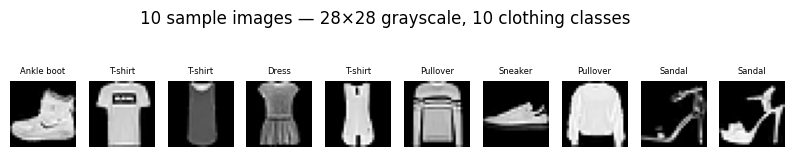

In [ ]:

# ── Sample images ──────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_train[i, :, :, 0], cmap='gray')   # [i,:,:,0] = image i, drop channel axis for display
    plt.title(class_names[int(y_train[i])], fontsize=6)
    plt.axis('off')
plt.suptitle('10 sample images — 28×28 grayscale, 10 clothing classes', y=1.02); plt.show()

## 2 - Build the CNN
A CNN reads an image by sliding small **filters** over it. Each filter is a tiny
pattern detector (an edge, a curve, a texture); a layer has many filters so it can
spot many patterns at once.

- **Conv2D(32, 3)** — 32 filters, each 3x3 pixels. `padding='same'` adds a zero border
  so the output stays the same width/height as the input.
- **ReLU** — an activation that keeps positive signals and zeroes out negatives; it lets
  the network learn non-straight-line patterns.
- **MaxPool(2x2)** — shrinks the image by half, keeping the strongest signal in each
  2x2 patch (less data, keeps the important bits).
- **Flatten → Dense** — unroll the 2D feature maps into a flat list, then ordinary
  fully-connected layers make the final 10-class decision.

```
Input (28,28,1)
  → Conv2D(32, 3x3) + ReLU      # detect edges / textures   -> 28x28
  → MaxPool(2x2)                # halve spatial size         -> 14x14
  → Conv2D(64, 3x3) + ReLU      # detect higher-level shapes -> 14x14
  → MaxPool(2x2)                # halve again                -> 7x7
  → Conv2D(64, 3x3) + ReLU      #                            -> 7x7
  → Flatten → Dropout → Dense(64) → Dense(10 logits)
```
Filter counts (32, 64) grow as the image shrinks — a common pattern, not a hard rule.

In [ ]:
def build_cnn(dropout_rate=0.0):
    # dropout_rate=0.0 means the Dropout layer does nothing (we turn it on in Section 5).
    return models.Sequential([
        layers.Input((28, 28, 1)),
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.Flatten(),
        layers.Dropout(dropout_rate),
        layers.Dense(64, activation='relu'),
        layers.Dense(10),                      # 10 raw scores (logits), one per class
    ])

cnn = build_cnn(dropout_rate=0.0)
cnn.summary()
print(f'\nTotal parameters: {cnn.count_params():,}')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257,162 (1004.54 KB)

 Trainable params: 257,162 (1004.54 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 257,162


## 3 - Train and read the curves
We now **compile** (pick the optimizer + loss) and **fit** (train) the model.

- `optimizer='adam'` — a reliable default optimizer.
- `SparseCategoricalCrossentropy(from_logits=True)` — the loss for multi-class labels.
  *Sparse* means our labels are plain integers (0-9), not one-hot vectors. *from_logits=True*
  tells the loss our last layer outputs raw scores, so it applies the softmax internally
  (that's why we left `Dense(10)` with no activation).
- `epochs=10` — ten passes over the data. `batch_size=64` — update after every 64 images.
- `validation_split=0.1` — Keras holds back 10% of the **training** data and checks
  accuracy on it after each epoch. This is *separate* from the test set, which we never
  touch until the very end. Comparing train vs validation is how we spot overfitting.

In [ ]:
cnn.compile(optimizer='adam',
            loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
            metrics=['accuracy'])

# verbose=2 prints one summary line per epoch (use 0 for silent, 1 for a progress bar).
history = cnn.fit(x_train, y_train, epochs=10, batch_size=64,
                  validation_split=0.1, verbose=2)

test_acc = cnn.evaluate(x_test, y_test, verbose=0)[1]   # evaluate() returns [loss, accuracy]; [1] = accuracy
print(f'\nTest accuracy: {test_acc:.1%}')

Epoch 1/10
141/141 - 18s - 127ms/step - accuracy: 0.7059 - loss: 0.8079 - val_accuracy: 0.7870 - val_loss: 0.5630
Epoch 2/10
141/141 - 12s - 87ms/step - accuracy: 0.8242 - loss: 0.4806 - val_accuracy: 0.8260 - val_loss: 0.4762
Epoch 3/10
141/141 - 13s - 89ms/step - accuracy: 0.8569 - loss: 0.4026 - val_accuracy: 0.8510 - val_loss: 0.3988
Epoch 4/10
141/141 - 12s - 87ms/step - accuracy: 0.8751 - loss: 0.3502 - val_accuracy: 0.8650 - val_loss: 0.3689
Epoch 5/10
141/141 - 12s - 86ms/step - accuracy: 0.8881 - loss: 0.3117 - val_accuracy: 0.8710 - val_loss: 0.3558
Epoch 6/10
141/141 - 21s - 146ms/step - accuracy: 0.9027 - loss: 0.2764 - val_accuracy: 0.8740 - val_loss: 0.3510
Epoch 7/10
141/141 - 12s - 87ms/step - accuracy: 0.9103 - loss: 0.2496 - val_accuracy: 0.8820 - val_loss: 0.3550
Epoch 8/10
141/141 - 13s - 89ms/step - accuracy: 0.9214 - loss: 0.2265 - val_accuracy: 0.8890 - val_loss: 0.3458
Epoch 9/10
141/141 - 13s - 89ms/step - accuracy: 0.9279 - loss: 0.2057 - val_accuracy: 0.8920 

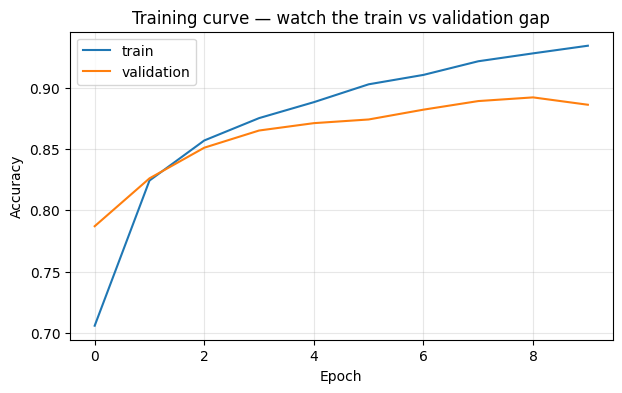

Final train-val gap: 4.8%  (a widening gap is the warning sign of overfitting)


In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(history.history['accuracy'],     label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('Training curve — watch the train vs validation gap')
plt.legend(); plt.grid(alpha=0.3); plt.show()

# If TRAIN accuracy climbs well above VALIDATION accuracy, the model is memorising
# the training data (overfitting) rather than learning general patterns.
gap = history.history['accuracy'][-1] - history.history['val_accuracy'][-1]
print(f'Final train-val gap: {gap:.1%}  (a widening gap is the warning sign of overfitting)')

## 4 - Where does it fail?
A single accuracy number hides *which* classes are hard. Two closer looks:
a per-class report, then the actual images the model got wrong.

In [ ]:
from sklearn.metrics import classification_report

# cnn.predict() returns 10 raw scores (logits) per image — one per class.
logits = cnn.predict(x_test, verbose=0)       # shape (2000, 10): 2000 images × 10 class scores
pred   = np.argmax(logits, axis=1)            # pick the index of the HIGHEST score → predicted class
true   = y_test.flatten()                     # ground-truth class index for each image

# Quick sanity check: see the raw scores for one image before argmax
print(f'Logits for image #0   : {logits[0].round(1)}')   # 10 numbers, one per class
print(f'Predicted (argmax)    : {pred[0]}  → {class_names[pred[0]]}')
print(f'True label            : {true[0]}  → {class_names[true[0]]}')
print()
print(classification_report(true, pred, target_names=class_names, digits=2))

Logits for image #0   : [-3.7 -2.4 -2.6 -4.1 -5.2  0.2 -6.5  6.7  3.5  9.4]
Predicted (argmax)    : 9  → Ankle boot
True label            : 9  → Ankle boot

              precision    recall  f1-score   support

     T-shirt       0.87      0.82      0.85       200
     Trouser       0.99      0.98      0.99       203
    Pullover       0.88      0.76      0.81       214
       Dress       0.91      0.83      0.87       190
        Coat       0.81      0.79      0.80       219
      Sandal       0.97      0.93      0.95       195
       Shirt       0.60      0.81      0.69       197
     Sneaker       0.85      0.98      0.91       200
         Bag       0.96      0.95      0.96       194
  Ankle boot       0.99      0.87      0.93       188

    accuracy                           0.87      2000
   macro avg       0.88      0.87      0.87      2000
weighted avg       0.88      0.87      0.87      2000



**How to read that table.** Each row is one clothing class.
- **precision** — of everything the model *called* this class, how much was right.
- **recall** — of all the *real* examples of this class, how many it found.
- **f1-score** — a single balance of precision and recall (1.0 = perfect).
- **support** — how many test images belong to that class.

Look for the lowest f1 row — usually **Shirt**, because in low-res grayscale a shirt
looks a lot like a T-shirt, pullover, or coat. The images below show these confusions.

Misclassified: 259 / 2000


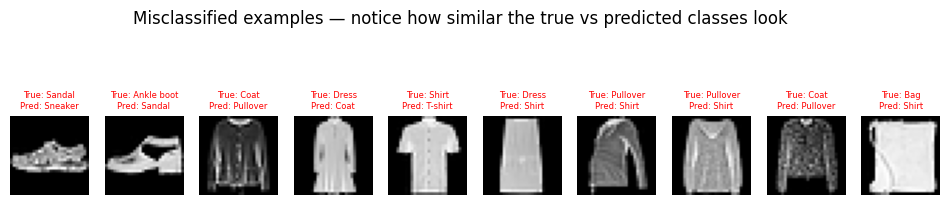

In [ ]:
# Show 10 images the model got wrong
wrong = np.where(pred != true)[0]    # indices where prediction != truth
print(f'Misclassified: {len(wrong)} / {len(true)}')

plt.figure(figsize=(12, 2.5))
for col, idx in enumerate(wrong[:10]):
    plt.subplot(1, 10, col+1)
    plt.imshow(x_test[idx, :, :, 0], cmap='gray')
    plt.title(f'True: {class_names[true[idx]]}\nPred: {class_names[pred[idx]]}',
              fontsize=6, color='red')
    plt.axis('off')
plt.suptitle('Misclassified examples — notice how similar the true vs predicted classes look', y=1.08)
plt.show()

## 5 - Improve: add Dropout
**Dropout** is the standard tool against overfitting. During *training only*, it randomly
zeroes a fraction (here 30%) of a layer's outputs each step, so the network can't lean on
any single feature and must learn sturdier, more general ones. At test time Dropout is off
and the full network is used.

Our baseline just crossed the overfitting warning line (train-val gap ~5%), so this is a
good moment to add Dropout. Watch two things after we retrain: the train-val gap should
*shrink*, and test accuracy should *rise* a little (the model generalises better).
We rebuild with `dropout_rate=0.3` and compare.

In [ ]:
cnn_drop = build_cnn(dropout_rate=0.3)
cnn_drop.compile(optimizer='adam',
                 loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                 metrics=['accuracy'])

history_drop = cnn_drop.fit(x_train, y_train, epochs=10, batch_size=64,
                             validation_split=0.1, verbose=2)

test_acc_drop = cnn_drop.evaluate(x_test, y_test, verbose=0)[1]
print(f'\nBaseline  test accuracy: {test_acc:.1%}')
print(f'+ Dropout test accuracy: {test_acc_drop:.1%}')

Epoch 1/10
141/141 - 15s - 107ms/step - accuracy: 0.6913 - loss: 0.8440 - val_accuracy: 0.8030 - val_loss: 0.5626
Epoch 2/10
141/141 - 16s - 112ms/step - accuracy: 0.8213 - loss: 0.4918 - val_accuracy: 0.8440 - val_loss: 0.4421
Epoch 3/10
141/141 - 17s - 124ms/step - accuracy: 0.8522 - loss: 0.4063 - val_accuracy: 0.8520 - val_loss: 0.4084
Epoch 4/10
141/141 - 13s - 91ms/step - accuracy: 0.8680 - loss: 0.3652 - val_accuracy: 0.8670 - val_loss: 0.3797
Epoch 5/10
141/141 - 20s - 140ms/step - accuracy: 0.8811 - loss: 0.3303 - val_accuracy: 0.8830 - val_loss: 0.3574
Epoch 6/10
141/141 - 12s - 86ms/step - accuracy: 0.8926 - loss: 0.2972 - val_accuracy: 0.8750 - val_loss: 0.3592
Epoch 7/10
141/141 - 12s - 88ms/step - accuracy: 0.9007 - loss: 0.2760 - val_accuracy: 0.8880 - val_loss: 0.3363
Epoch 8/10
141/141 - 21s - 149ms/step - accuracy: 0.9058 - loss: 0.2568 - val_accuracy: 0.8770 - val_loss: 0.3553
Epoch 9/10
141/141 - 13s - 89ms/step - accuracy: 0.9124 - loss: 0.2351 - val_accuracy: 0.88

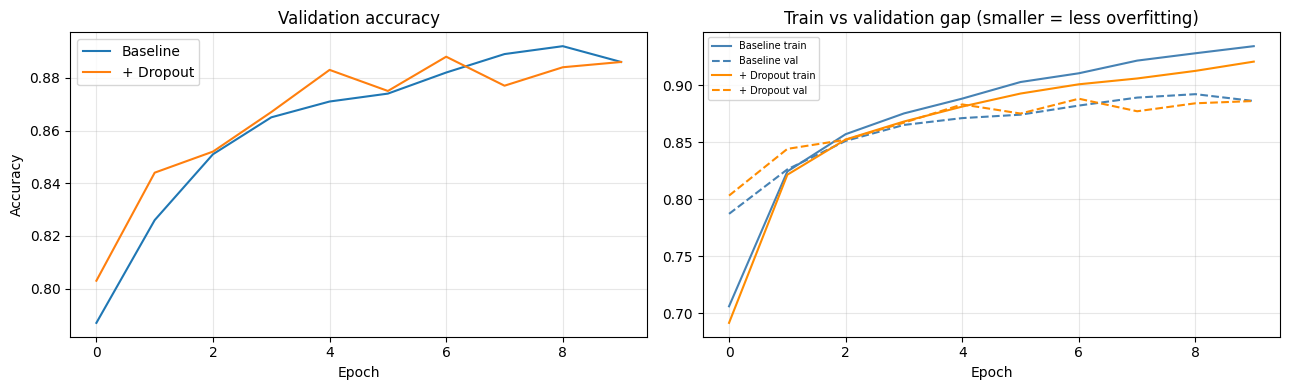

Train-val gap  Baseline: 4.8%  |  + Dropout: 3.5%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['val_accuracy'],      label='Baseline')
axes[0].plot(history_drop.history['val_accuracy'], label='+ Dropout')
axes[0].set_title('Validation accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'],          label='Baseline train',   color='steelblue')
axes[1].plot(history.history['val_accuracy'],      label='Baseline val',     color='steelblue', linestyle='--')
axes[1].plot(history_drop.history['accuracy'],     label='+ Dropout train',  color='darkorange')
axes[1].plot(history_drop.history['val_accuracy'], label='+ Dropout val',    color='darkorange', linestyle='--')
axes[1].set_title('Train vs validation gap (smaller = less overfitting)')
axes[1].set_xlabel('Epoch'); axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

gap_base = history.history['accuracy'][-1]      - history.history['val_accuracy'][-1]
gap_drop = history_drop.history['accuracy'][-1] - history_drop.history['val_accuracy'][-1]
print(f'Train-val gap  Baseline: {gap_base:.1%}  |  + Dropout: {gap_drop:.1%}')

## 6 - What else you can try
Each technique below is a small change. The biggest wins come from more data and
(for small datasets) transfer learning.

### More data (biggest win)
```python
# Remove the slice — use all 60 000 training images
x_train, y_train = ...   # delete the [:10000] / [:2000] lines above
```
Same architecture on the full set typically reaches **~90-92%**.

### Data augmentation (when you can't get more data)
```python
data_aug = keras.Sequential([
    layers.RandomFlip('horizontal'),   # horizontal only — a vertically flipped shoe isn't realistic
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])
# Insert right after layers.Input(...) so every training image is randomly varied.
```
Creates fresh variations each epoch, which reduces overfitting.

### Batch Normalisation (faster, steadier training)
Replace each `Conv2D(..., activation='relu')` with the three-line form below
(Conv with no activation → normalise → then activate):
```python
layers.Conv2D(64, 3, padding='same'),   # no activation here
layers.BatchNormalization(),
layers.Activation('relu'),
```

### More epochs + a learning-rate schedule
```python
lr_schedule = keras.optimizers.schedules.CosineDecay(1e-3, decay_steps=1000)
cnn.compile(optimizer=keras.optimizers.Adam(lr_schedule), ...)   # then train 20-30 epochs
```

### Transfer learning (biggest jump for small datasets)
Reuse a network pretrained on millions of images as a feature extractor — covered in
`Transfer_Learning_Beginner.ipynb`.

---
# Part 2 - RNN: Understanding Recurrent Neural Networks
*Based on Chollet, Deep Learning with Python, Chapter 6.2*

You've built an image classifier. Now we switch to **text** — a completely different
kind of data where **order matters**. "not good" and "good, not bad" use similar words
but mean opposite things, so the model must read the sequence in order and carry memory
of what came before.

- A **CNN** is built for *spatial* structure (nearby pixels).
- An **RNN** is built for *sequential* structure (words over time). It reads one item at
  a time and keeps a running **hidden state** — a memory vector updated at each step.

**Task**: IMDB movie-review sentiment (positive vs negative). Two models:
- `SimpleRNN` — the basic recurrent layer; struggles to remember long-range context.
- `LSTM` — a smarter recurrent layer with internal "gates" that handle long context.

## 7 - Load IMDB reviews
The reviews are already **tokenised**: each word is replaced by a number — its rank in
the vocabulary (so 1 = most common word, 2 = next, …). `num_words=10000` keeps only the
top 10 000 words and drops the rest.

Reviews vary in length, but a network needs fixed-size input, so `pad_sequences` makes
every review exactly 500 numbers long: longer reviews are cut, shorter ones are
**left-padded with 0s** at the front. (That's why the start of a short review prints as
zeros — they're padding, not real words.)

In [ ]:
from tensorflow.keras.utils import pad_sequences   # modern import location
from tensorflow.keras.datasets import imdb

max_features = 10000   # keep the 10,000 most common words; rare words are dropped
maxlen       = 500     # every review will be padded/truncated to exactly this length

# Each review is stored as a list of integers (word ranks), NOT actual words yet.
# y = 1 → positive review, 0 → negative.
(x_tr, y_tr), (x_te, y_te) = imdb.load_data(num_words=max_features)

# ── Step 1: What does one raw review look like? ────────────────────────────────
print("=== RAW data (before any processing) ===")
print(f"Type of one review : {type(x_tr[0])}")        # a plain Python list
print(f"First 15 tokens    : {x_tr[0][:15]} ...")     # integers, not words yet
print(f"Label              : {y_tr[0]}  ({'POSITIVE' if y_tr[0] else 'NEGATIVE'})")
print()

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
=== RAW data (before any processing) ===
Type of one review : <class 'list'>
First 15 tokens    : [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4] ...
Label              : 1  (POSITIVE)



In [ ]:
# ── Step 2: Reviews are VARIABLE length — a network needs FIXED size ──────────
lengths = [len(r) for r in x_tr]
print("=== Review lengths (this is the problem pad_sequences solves) ===")
print(f"Shortest : {min(lengths)} words")
print(f"Longest  : {max(lengths)} words")
print(f"Average  : {int(np.mean(lengths))} words")
print(f"First 8  : {lengths[:8]}")    # all different — can't build a matrix yet
print()

=== Review lengths (this is the problem pad_sequences solves) ===
Shortest : 11 words
Longest  : 2494 words
Average  : 238 words
First 8  : [218, 189, 141, 550, 147, 43, 123, 562]



In [ ]:
# ── Step 3: Decode integers → real English words ──────────────────────────────
# imdb.get_word_index() returns {'the': 1, 'and': 2, ...}
# We flip it → {1: 'the', 2: 'and', ...} so we can look up numbers → words.
# The dataset reserves indices 0-3 for special tokens; real words start at offset +3.
word_index    = imdb.get_word_index()
reverse_index = {rank + 3: word for word, rank in word_index.items()}
reverse_index[0] = '<PAD>'    # 0 = padding (added next step to fill short reviews)
reverse_index[1] = '<START>'  # marks the beginning of every stored review
reverse_index[2] = '<UNK>'    # unknown / dropped rare word

def decode_review(tokens, n=25):
    # Show the last n words of a review - the end carries the core sentiment.
    return ' '.join(reverse_index.get(t, '?') for t in tokens[-n:])

print("=== One review decoded into English (last 25 words) ===")
print(f"...{decode_review(x_tr[0])}")
print()


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
=== One review decoded into English (last 25 words) ===
...don't you think the whole story was so lovely because it was true and was someone's life after all that was shared with us all



In [ ]:

# ── Step 4: pad_sequences → make every review exactly 500 tokens ──────────────
# SHORT reviews (< 500 words) → padded with 0s at the FRONT  (left-pad)
# LONG  reviews (> 500 words) → truncated from the FRONT     (keep the end)
# Result: x_tr becomes a proper 2-D matrix of shape (25000, 500)
x_tr = pad_sequences(x_tr, maxlen=maxlen)
x_te = pad_sequences(x_te, maxlen=maxlen)

print("=== AFTER pad_sequences ===")
print(f"Shape : {x_tr.shape}   ← every review is now exactly {maxlen} tokens")
print(f"Start of review #0  (zeros = padding)  : {x_tr[0][:12]}")
print(f"End   of review #0  (real word tokens) : {x_tr[0][-12:]}")
print()

# ── Step 5: Label balance — always check this before training ─────────────────
pos = int(y_tr.sum())
neg = len(y_tr) - pos
print("=== Label balance (train set) ===")
print(f"Positive: {pos}  |  Negative: {neg}  ← perfectly balanced")
print("50% accuracy = random guessing; anything above = the model is actually learning.")

=== AFTER pad_sequences ===
Shape : (25000, 500)   ← every review is now exactly 500 tokens
Start of review #0  (zeros = padding)  : [0 0 0 0 0 0 0 0 0 0 0 0]
End   of review #0  (real word tokens) : [   5   16 4472  113  103   32   15   16 5345   19  178   32]

=== Label balance (train set) ===
Positive: 12500  |  Negative: 12500  ← perfectly balanced
50% accuracy = random guessing; anything above = the model is actually learning.


## 8 - SimpleRNN
The model has three layers:
- **Embedding(10000, 32)** — a learned lookup table turning each word-number into a
  32-number vector. Raw indices like 218 and 219 mean nothing numerically; the embedding
  learns vectors so that words used in similar ways end up close together.
- **SimpleRNN(32)** — reads the 500 word-vectors in order, carrying a 32-number memory
  (hidden state) updated at each word:  `h_t = tanh(W_x · x_t + W_h · h_{t-1})`.
  Here `x_t` is the current word, `h_{t-1}` the memory so far, and `tanh` squashes values
  to the −1…1 range.
- **Dense(1, sigmoid)** — one output squashed to 0-1, read as P(positive). We use
  `binary_crossentropy` because there are exactly two classes (vs the 10-class CNN).

**The catch:** while training a SimpleRNN over 500 steps, the error signal shrinks as it
travels back through time (the *vanishing gradient*), so the layer learns long-range
dependencies poorly and generalises unevenly. That's what LSTM fixes.


`Embedding(max_features, 32)` has two separate jobs:

| Argument | Value | What it controls |
|---|---|---|
| `max_features` | 10,000 | **Table size** — one row per word in the vocabulary |
| `32` | 32 | **Embedding dimension** — each word → a 32-number vector |

`max_features` never appears in the output shape. What does appear:

Input → (batch, 500) ← 500 integer word IDs per review
↓ lookup in the 10,000 × 32 table
Output → (batch, 500, 32) ← 500 word vectors, each 32 numbers long


**Verify with the param count:** 10,000 rows × 32 columns = **320,000 parameters** — matches the summary.

The model has three layers:
- **Embedding(10000, 32)** — turns word IDs into dense vectors; words used in similar contexts end up close together in the 32-D space.
- **SimpleRNN(32)** — reads the 500 word-vectors one at a time, carrying a 32-number memory: `h_t = tanh(W · x_t + U · h_{t-1})`. The catch: over 500 steps, the error signal shrinks as it travels back through time (*vanishing gradient*), so long-range context is lost.
- **Dense(1, sigmoid)** — squashes to 0–1 probability (P = positive review). Two classes → `binary_crossentropy`, not the 10-class `SparseCategoricalCrossentropy` we used for Fashion-MNIST.

In [ ]:
rnn_simple = models.Sequential([
    layers.Embedding(max_features, 32),
    layers.SimpleRNN(32),
    layers.Dense(1, activation='sigmoid'),
], name='SimpleRNN')

# rmsprop is a common optimizer choice for RNNs; adam also works.
rnn_simple.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
rnn_simple.build(input_shape=(None, maxlen))   # build now so summary shows real param counts
rnn_simple.summary()

Model: "SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,113 (1.23 MB)

 Trainable params: 322,113 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
hist_rnn = rnn_simple.fit(x_tr, y_tr, epochs=5, batch_size=128,
                          validation_split=0.2, verbose=2)
rnn_acc = rnn_simple.evaluate(x_te, y_te, verbose=0)[1]
print(f'\nSimpleRNN test accuracy: {rnn_acc:.1%}')

Epoch 1/5
157/157 - 27s - 172ms/step - accuracy: 0.6137 - loss: 0.6451 - val_accuracy: 0.7574 - val_loss: 0.5174
Epoch 2/5
157/157 - 26s - 163ms/step - accuracy: 0.7936 - loss: 0.4536 - val_accuracy: 0.7456 - val_loss: 0.5128
Epoch 3/5
157/157 - 41s - 259ms/step - accuracy: 0.8514 - loss: 0.3575 - val_accuracy: 0.8424 - val_loss: 0.3785
Epoch 4/5
157/157 - 41s - 261ms/step - accuracy: 0.8967 - loss: 0.2625 - val_accuracy: 0.8234 - val_loss: 0.4096
Epoch 5/5
157/157 - 25s - 161ms/step - accuracy: 0.9263 - loss: 0.1953 - val_accuracy: 0.8236 - val_loss: 0.4399

SimpleRNN test accuracy: 82.2%


## 9 - LSTM
An **LSTM** is a recurrent layer with a separate **cell state** (a long-term memory
conveyor belt) controlled by three **gates** — small sigmoid switches that learn what to
keep, add, and output:

- **Forget gate** — how much of the old memory to keep.
- **Input gate** — how much new information to write in.
- **Output gate** — how much of the memory to expose as this step's hidden state.

Because the cell state flows along with only light, gated edits, the error signal survives
across many steps — so long-range context is preserved where SimpleRNN loses it.

> *Optional — the actual equations (skip if the intuition above is enough):*
> ```
> f_t = sigmoid(W_f · [h_{t-1}, x_t])      # forget gate
> i_t = sigmoid(W_i · [h_{t-1}, x_t])      # input gate
> o_t = sigmoid(W_o · [h_{t-1}, x_t])      # output gate
> C_t = f_t * C_{t-1} + i_t * tanh(W_C · [h_{t-1}, x_t])   # update cell state (memory)
> h_t = o_t * tanh(C_t)                    # hidden state we pass on / read out
> ```
> `[h_{t-1}, x_t]` is the previous memory and current word joined together; `·` is a
> weighted sum; `*` is element-wise.

Same data, same Embedding, same 32 units — only the recurrent cell changes.

In [ ]:
rnn_lstm = models.Sequential([
    layers.Embedding(max_features, 32),
    layers.LSTM(32),
    layers.Dense(1, activation='sigmoid'),
], name='LSTM')

rnn_lstm.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
hist_lstm = rnn_lstm.fit(x_tr, y_tr, epochs=5, batch_size=128,
                         validation_split=0.2, verbose=2)
lstm_acc = rnn_lstm.evaluate(x_te, y_te, verbose=0)[1]

print(f'\nRecap  SimpleRNN test accuracy: {rnn_acc:.1%}')
print(f'       LSTM      test accuracy: {lstm_acc:.1%}')
print(f'LSTM improves over SimpleRNN by: {lstm_acc - rnn_acc:+.1%}')

Epoch 1/5
157/157 - 51s - 326ms/step - accuracy: 0.6763 - loss: 0.5931 - val_accuracy: 0.8058 - val_loss: 0.4506
Epoch 2/5
157/157 - 47s - 302ms/step - accuracy: 0.8317 - loss: 0.3960 - val_accuracy: 0.8146 - val_loss: 0.4352
Epoch 3/5
157/157 - 82s - 523ms/step - accuracy: 0.8633 - loss: 0.3369 - val_accuracy: 0.8746 - val_loss: 0.3049
Epoch 4/5
157/157 - 82s - 523ms/step - accuracy: 0.8767 - loss: 0.3076 - val_accuracy: 0.8084 - val_loss: 0.4467
Epoch 5/5
157/157 - 47s - 298ms/step - accuracy: 0.8937 - loss: 0.2700 - val_accuracy: 0.8160 - val_loss: 0.4094

Recap  SimpleRNN test accuracy: 82.2%
       LSTM      test accuracy: 81.2%
LSTM improves over SimpleRNN by: -1.0%


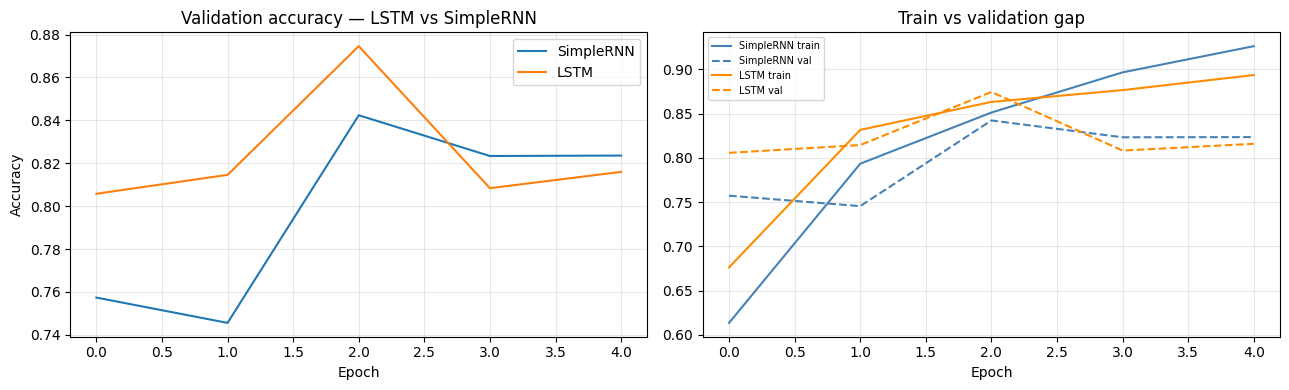

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(hist_rnn.history['val_accuracy'],  label='SimpleRNN')
axes[0].plot(hist_lstm.history['val_accuracy'], label='LSTM')
axes[0].set_title('Validation accuracy — LSTM vs SimpleRNN')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist_rnn.history['accuracy'],      label='SimpleRNN train', color='steelblue')
axes[1].plot(hist_rnn.history['val_accuracy'],  label='SimpleRNN val',   color='steelblue', linestyle='--')
axes[1].plot(hist_lstm.history['accuracy'],     label='LSTM train',      color='darkorange')
axes[1].plot(hist_lstm.history['val_accuracy'], label='LSTM val',        color='darkorange', linestyle='--')
axes[1].set_title('Train vs validation gap')
axes[1].set_xlabel('Epoch'); axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 10 - Compare and improve

| | CNN | RNN / LSTM |
|---|---|---|
| Data structure | Spatial (images, grids) | Sequential (text, time series, audio) |
| Core operation | Local patch filters | Hidden state carried across timesteps |
| Long-range info | Via pooling / depth | LSTM gates preserve it across many steps |
| Example task | Image classification | Sentiment, translation, forecasting |

**Rule of thumb**: match the architecture to the structure of your data — nearby pixels
→ CNN, ordered sequence → RNN/LSTM.

### How to push the LSTM further
- **Bidirectional** — read the sequence forwards *and* backwards:
  ```python
  layers.Bidirectional(layers.LSTM(32))
  ```
- **Stacked** — two recurrent layers (`return_sequences=True` on all but the last):
  ```python
  layers.LSTM(32, return_sequences=True),
  layers.LSTM(32),
  ```
- **GRU** — fewer gates than LSTM, often similar accuracy and faster:
  ```python
  layers.GRU(32)
  ```
- **1D CNN + LSTM** — a Conv1D first extracts local word patterns, then the LSTM reads them.
- **Transformers / attention** — the modern successor to RNNs for most NLP tasks.

**What you learned:** how to build, train, diagnose and improve both a CNN (images) and
an RNN/LSTM (text), and why each architecture fits its data.